<a href="https://colab.research.google.com/github/dytampn/TH_DeepLearning/blob/main/TH_DeepLearning_Tuan3_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
!pip install scikeras
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout

from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.preprocessing import MinMaxScaler

In [11]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [12]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


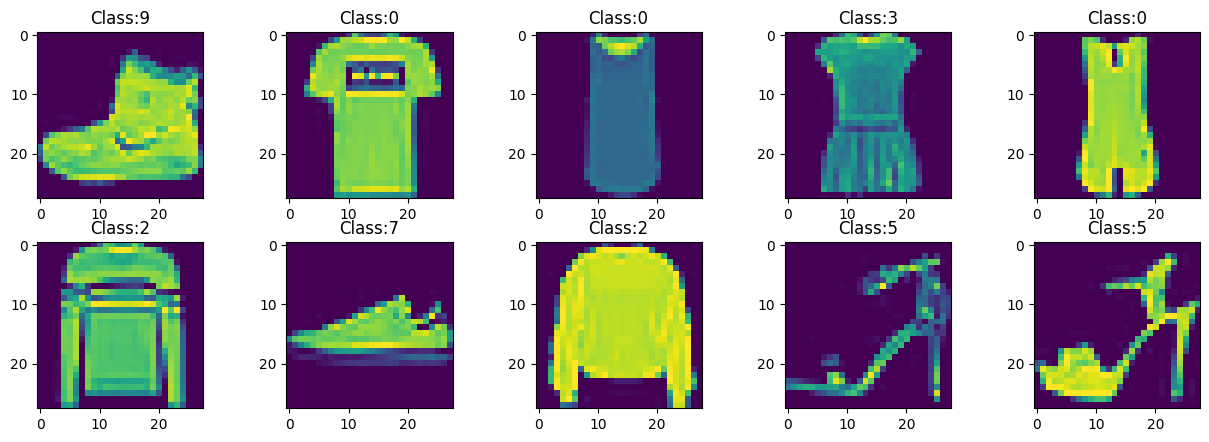

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize = (15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+ str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

In [14]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim = X_train.shape[1], units = 256, kernel_initializer='uniform', activation='relu'))

fashion_model.add(Dense(units = 10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_fit = fashion_model.fit(X_train, y_train, epochs=20, verbose=1, validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8207 - loss: 0.5069 - val_accuracy: 0.8525 - val_loss: 0.4144
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8647 - loss: 0.3714 - val_accuracy: 0.8688 - val_loss: 0.3540
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8762 - loss: 0.3330 - val_accuracy: 0.8715 - val_loss: 0.3454
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8871 - loss: 0.3078 - val_accuracy: 0.8823 - val_loss: 0.3219
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8940 - loss: 0.2881 - val_accuracy: 0.8817 - val_loss: 0.3350
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8984 - loss: 0.2737 - val_accuracy: 0.8878 - val_loss: 0.3179
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9034 - loss: 0.2595 - val_accuracy: 0.8867 - val_loss: 0.3228
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9061 - loss: 0.2

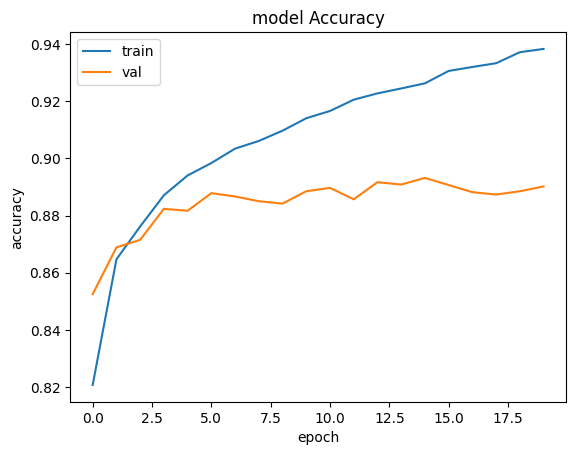

In [16]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

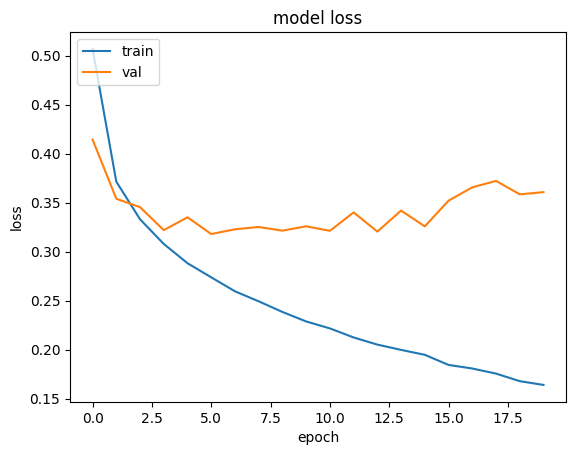

In [17]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [18]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
4 4


In [19]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head)
print(mnist_test.shape)

X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]
print('Number of Classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

<bound method NDFrame.head of        6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0      5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1      7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2      9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3      5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4      2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
...   .. ..  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...    ...   
19994  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19995  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19996  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19997  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19998  5  0    0    0    0    0    0    0    0    0  ...      0      0      0  

In [20]:
model = Sequential()
model.add(Dense(input_dim = X_train.shape[1], units = 256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units = 10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8752 - loss: 1.1897
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9385 - loss: 0.2198
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9500 - loss: 0.1887
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9458 - loss: 0.2173
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9502 - loss: 0.2178
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9520 - loss: 0.2120
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9551 - loss: 0.2080
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9608 - loss: 0.1870
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9613 - loss: 0.1991
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9648 - loss: 0.1736
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9672 - loss: 0.1650
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

In [25]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/tshirt.png', target_size=img_size, color_mode='grayscale'
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)

img_predict = model.predict(img_array)
print(img_predict)
scope = np.argmax(img_predict)
print(scope)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2 2
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.11145301 0.05931458 0.06066961 0.08085231 0.04945854 0.05634591
  0.05559458 0.0379676  0.41110343 0.07724036]]
8
